In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from pandas.plotting import lag_plot
import scipy
from scipy.stats import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from pyod.models.knn import KNN
from joblib import dump, load
from pyod.models.lof import LOF
from pyod.models.cblof import CBLOF
from pyod.models.iforest import IForest
from pyod.models.copod import COPOD
from pyod.models.mad import MAD
from sklearn.ensemble import IsolationForest
from pyod.models.ocsvm import OCSVM
# from pycaret.anomaly import *

from pathlib import Path
import warnings

warnings.simplefilter('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 7)

In [2]:
path = Path('/home/jeremy/Documents')

transaction = pd.read_excel(path / 'Transactions.xlsx')
transaction['Transaction_Date'] = transaction['Transaction Date']
cols = ['Amount', 'Transaction_Date']
transaction_df = transaction[cols]
# transaction = transaction.drop(columns='Transaction Date')
transaction.head()

,Trace ID,Posting Date,Account No,Description,Amount,Posting S,Posted,Account Name,Unit ID,Transaction Type,...,Entry No,Transaction Type Charges,Card Acceptor Terminal ID,ATM Card No,Customer Names,Process Code,Reference No,Is Coop Bank,POS Vendor,Transaction_Date
0,USSD-98209269-152052,2025-01-24,0101-005423900,USSD Withdrawal,3022.4,NaN,0,HABOYA TEI MKO,M-PESA,Withdrawal,...,3616322,Balance Enquiry,NaN,254795321709,NaN,NaN,NaN,0,ATM Lobby,2025-01-24
1,USSD-662078485-60422,2025-01-22,0109-007815700,USSD Withdrawal,2922.4,NaN,0,ERICK MUNGA,M-PESA,Withdrawal,...,3613622,Balance Enquiry,NaN,254702307923,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
2,USSD-716572205-64135,2025-01-22,0101-017171700,USSD Withdrawal,4022.4,NaN,0,OMAR MAKORANI WACHU,M-PESA,Withdrawal,...,3613352,Balance Enquiry,NaN,254729501490,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
3,USSD-715659342-85289,2025-01-22,0101-014659300,USSD Withdrawal,4022.4,NaN,0,STANLEY BARSIBOI CHEPKIRWOK,M-PESA,Withdrawal,...,3613210,Balance Enquiry,NaN,254722660045,NaN,NaN,NaN,0,ATM Lobby,2025-01-22
4,USSD-709957019-43649,2025-01-21,0101-021174300,USSD Withdrawal,2022.4,NaN,0,TIMAMU MWARAVINO CHEMBE,M-PESA,Withdrawal,...,3612562,Balance Enquiry,NaN,254112168233,NaN,NaN,NaN,0,ATM Lobby,2025-01-21


In [3]:
# transaction_df['Amount_Int'] = transaction_df['Amount'].astype(int)

In [4]:
transaction_df.head()

,Amount,Transaction_Date
0,3022.4,2025-01-24
1,2922.4,2025-01-22
2,4022.4,2025-01-22
3,4022.4,2025-01-22
4,2022.4,2025-01-21


In [5]:
# transaction_df.columns = transaction_df.columns.str.strip()
transaction_df['Transaction_Date'] = pd.to_datetime(transaction_df['Transaction_Date'])
transaction_df = transaction_df.set_index('Transaction_Date')
# transaction_df['Amount'] = pd.to_numeric(
#     transaction_df['Amount'].str.replace(',', ''), errors='coerce'
# )
transaction_df.head()

,Amount
Transaction_Date,
2025-01-24,3022.4
2025-01-22,2922.4
2025-01-22,4022.4
2025-01-22,4022.4
2025-01-21,2022.4


<Axes: xlabel='Transaction_Date'>

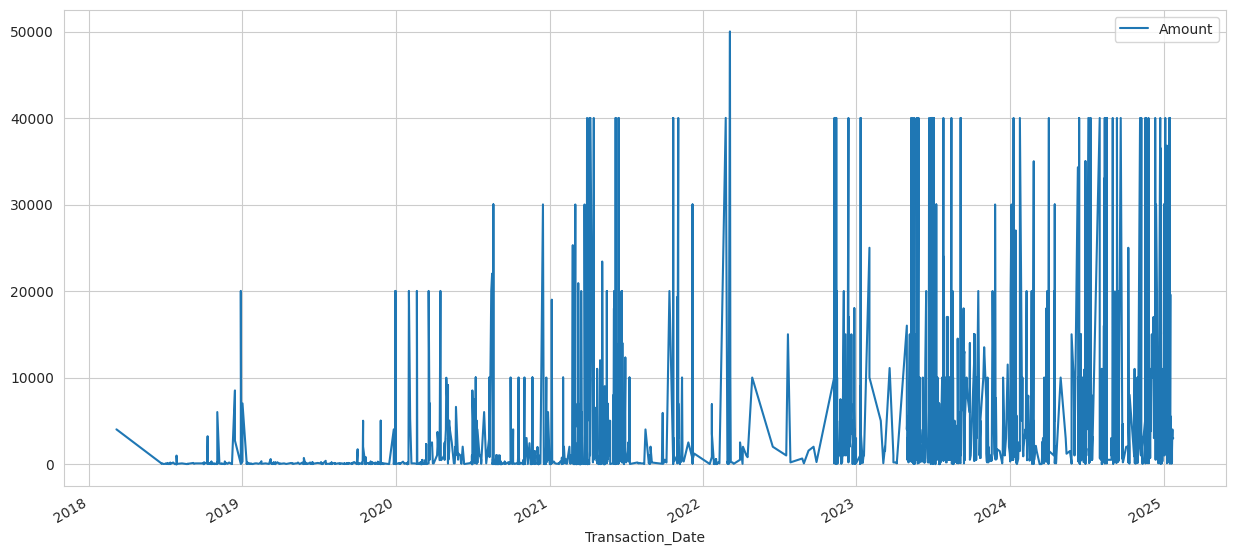

In [6]:
transaction_df.plot(figsize=(15,7))

In [7]:
transaction_df.isna().sum()

Amount    0
dtype: int64

In [38]:
# create plot_outliers function that will be used later in the recipes
def plot_outliers(outliers, df, method='KNN', halignment='right', valignment='bottom', labels=False):
    '''
    outliers: these are the known outliers dates like holidays
    df: dataframe to check and plot the outliers
    '''
    
    ax = df.plot(alpha=.6)

    if labels:
        for i in outliers['value'].items():
            plt.plot(i[0], i[1], 'rx', markersize=8, markerfacecolor='none', markeredgecolor='k')
            plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
    else:
        df.loc[outliers.index].plot(ax=ax, style='rx')

    plt.title(f'Transactions - {method}')
    plt.xlabel('date'); plt.ylabel('Number of Transactions')
    plt.legend(['transactions', 'outliers'])
    plt.show()

In [9]:
transaction_df = transaction_df.resample('21D').mean()

transaction_df.head()

,Amount
Transaction_Date,
2018-03-07,4032.0
2018-03-28,NaN
2018-04-18,NaN
2018-05-09,NaN
2018-05-30,NaN


In [10]:
transaction_df.isna().sum()

Amount    7
dtype: int64

In [11]:
transaction_dates = ['2022-04-27','2023-01-25','2024-12-18']

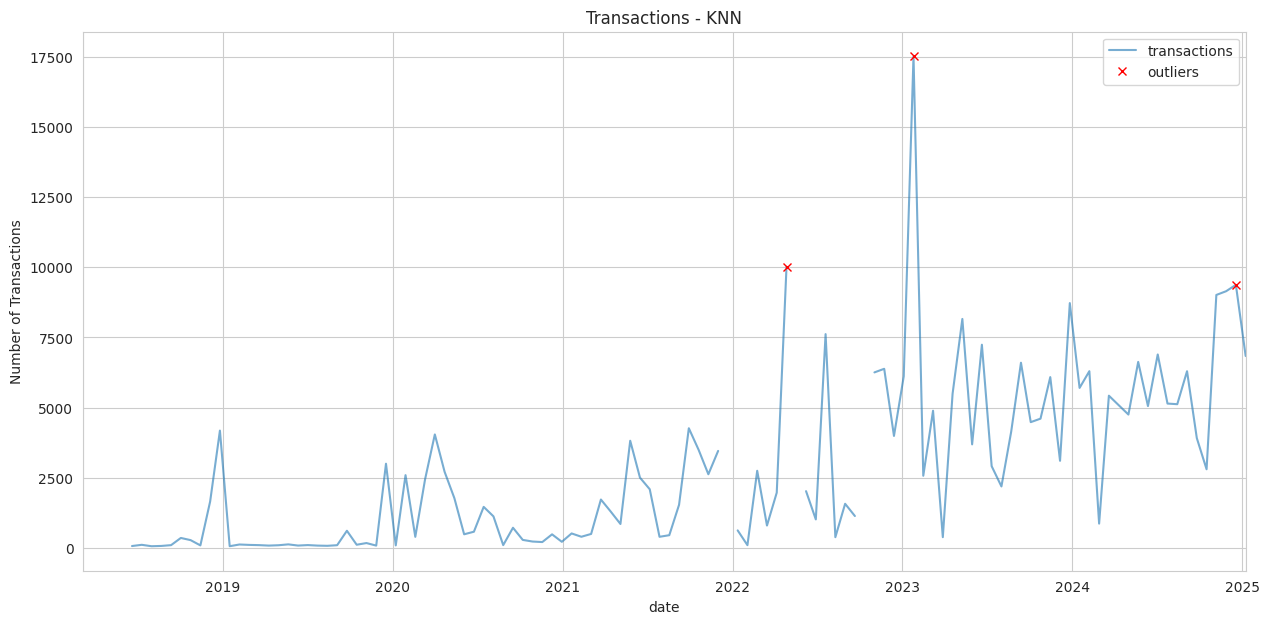

In [39]:
known_outliers = transaction_df.loc[transaction_dates]
plot_outliers(known_outliers, transaction_df, 'KNN')

<Axes: ylabel='Count'>

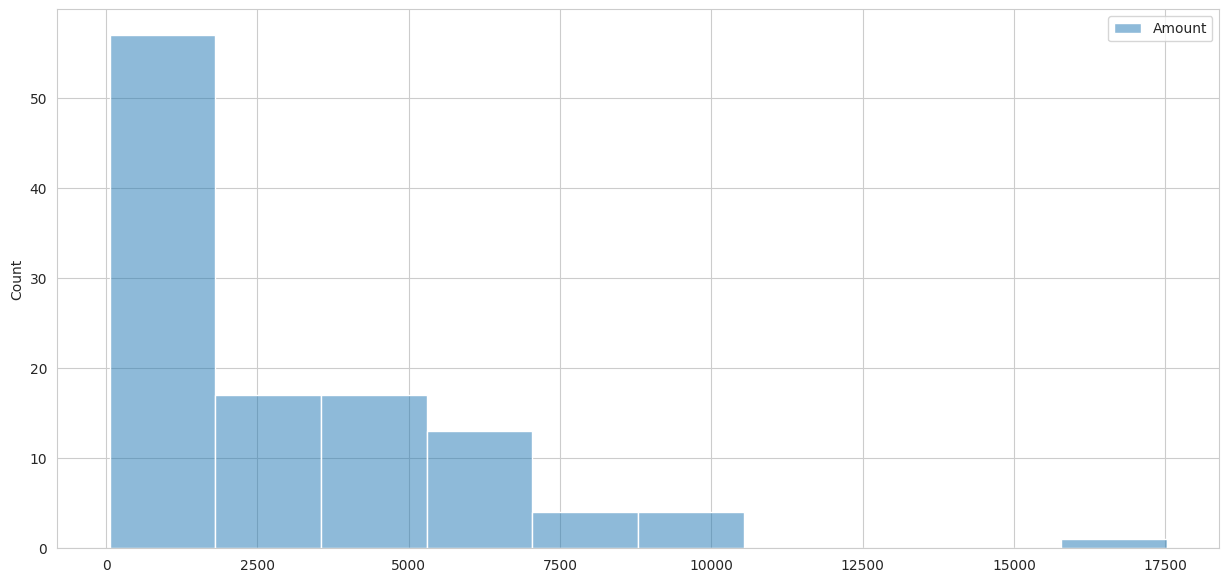

In [40]:
sns.histplot(transaction_df)

<Axes: xlabel='Transaction_Date'>

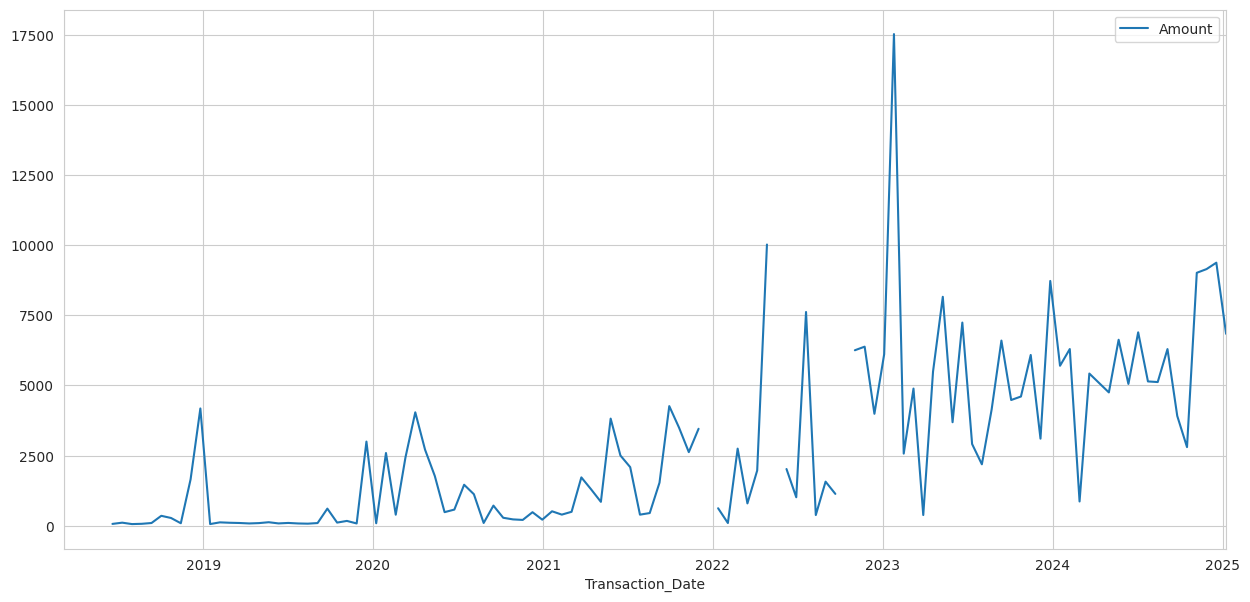

In [41]:
transaction_df.plot()

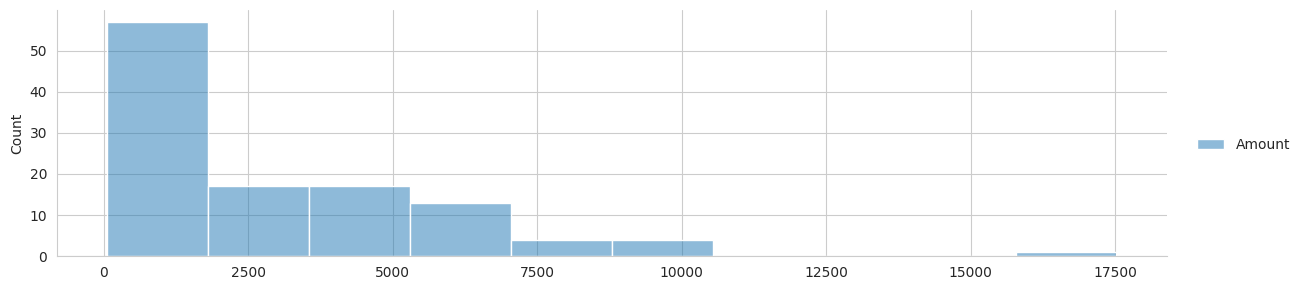

In [42]:
sns.displot(transaction_df, height=3, kind='hist', aspect=4)

<Axes: ylabel='Amount'>

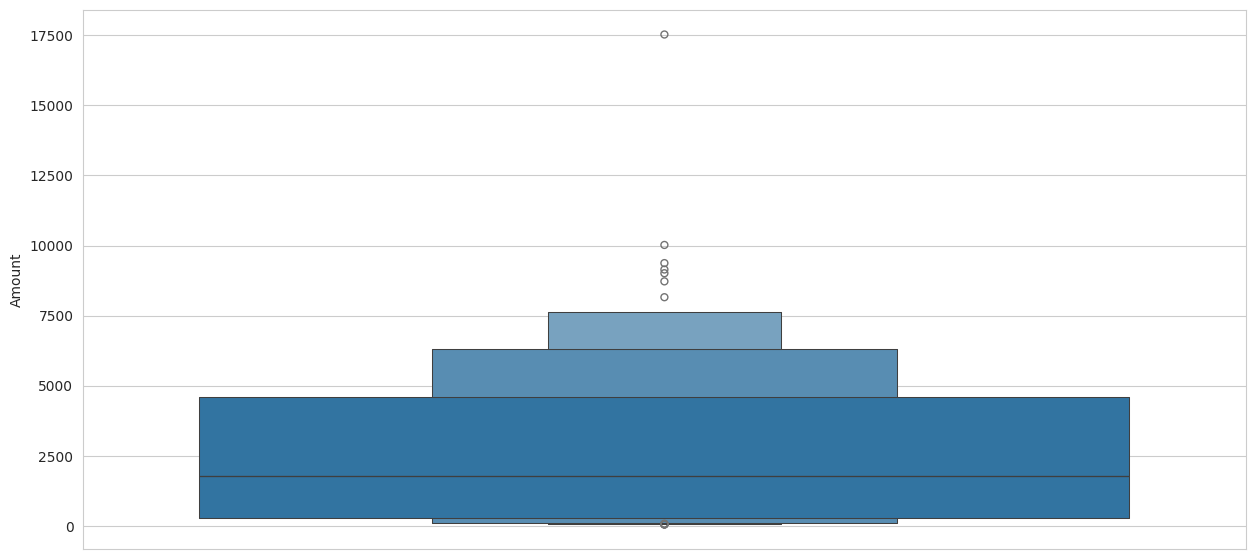

In [43]:
sns.boxenplot(transaction_df['Amount'])

You can filter the outliers in the box plot above by extracting amount greater than 7500.

<Axes: ylabel='Amount'>

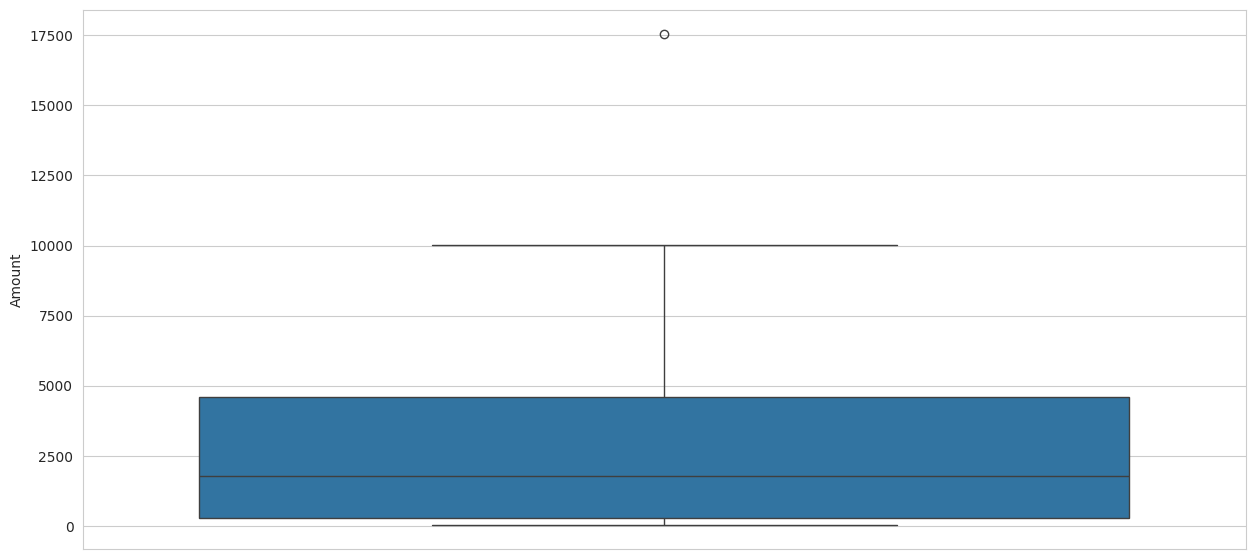

In [44]:
sns.boxplot(transaction_df['Amount'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

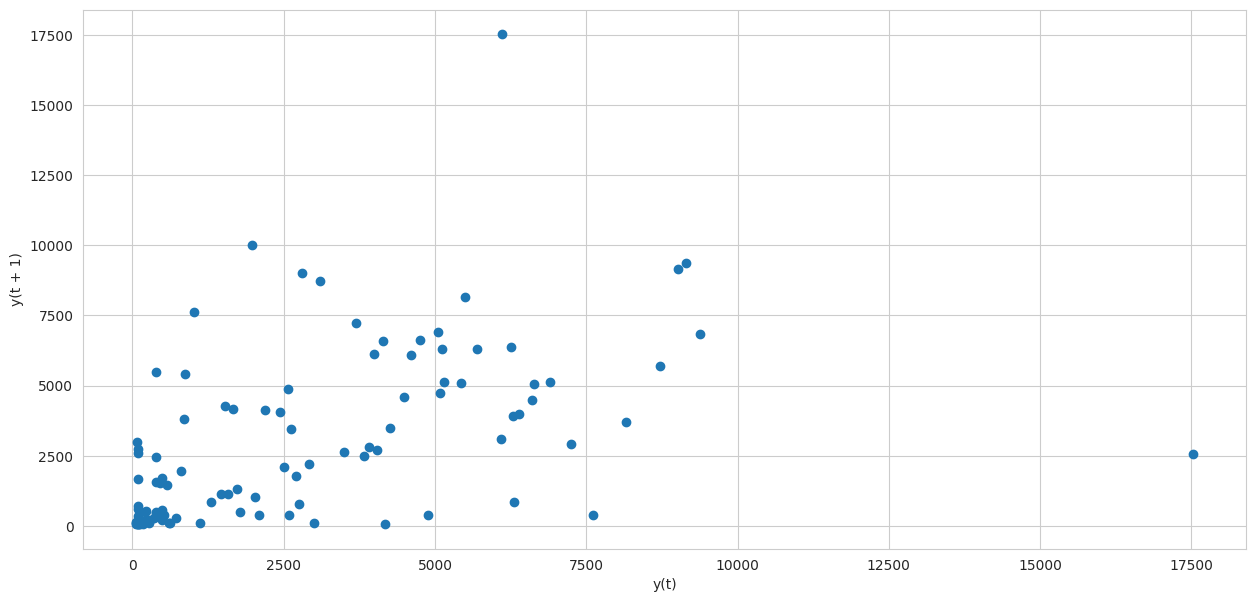

In [45]:
lag_plot(transaction_df)

It shows there is an autocorrelation between the values i.e future (predicted) values and previous values are correlated with each other.

In [19]:
#  Determine the outliers using Turkey fences
percentiles = [0, .05, .1, .25, .5, .75, .90, .95, 1]

transaction_df.describe(percentiles=percentiles)

,Amount
count,113.000000
mean,2795.354370
std,3026.593968
min,60.000000
0%,60.000000
5%,82.100000
10%,95.294118
25%,285.288889
50%,1773.125000
75%,4606.170909


In [20]:
def iqr_outliers(df, column_name):
    data = df[column_name]

    q1, q3 = np.percentile(df, [25, 75])
    iqr = q3 - q1
    
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    return df[(data < lower_fence) | (data > upper_fence)]

In [21]:
outliers = iqr_outliers(transaction_df, 'Amount')
outliers

,Amount
Transaction_Date,


In [23]:
scipy.stats.norm.ppf(0.75)         # normalization factor used in the formula

0.6744897501960817

In [27]:
def modified_z_score(df, degree=3):
    data = df.copy()
    s = scipy.stats.norm.ppf(0.75)
    numerator = s * (data - data.median())
    MAD = np.abs(data - data.median()).median()
    data['modified_zscore'] = numerator / MAD
    outliers = data[(data['modified_zscore'] > degree) | (data['modified_zscore'] < -degree)]

    return outliers['Amount'], data

array([[<Axes: title={'center': 'Amount'}>,
        <Axes: title={'center': 'modified_zscore'}>]], dtype=object)

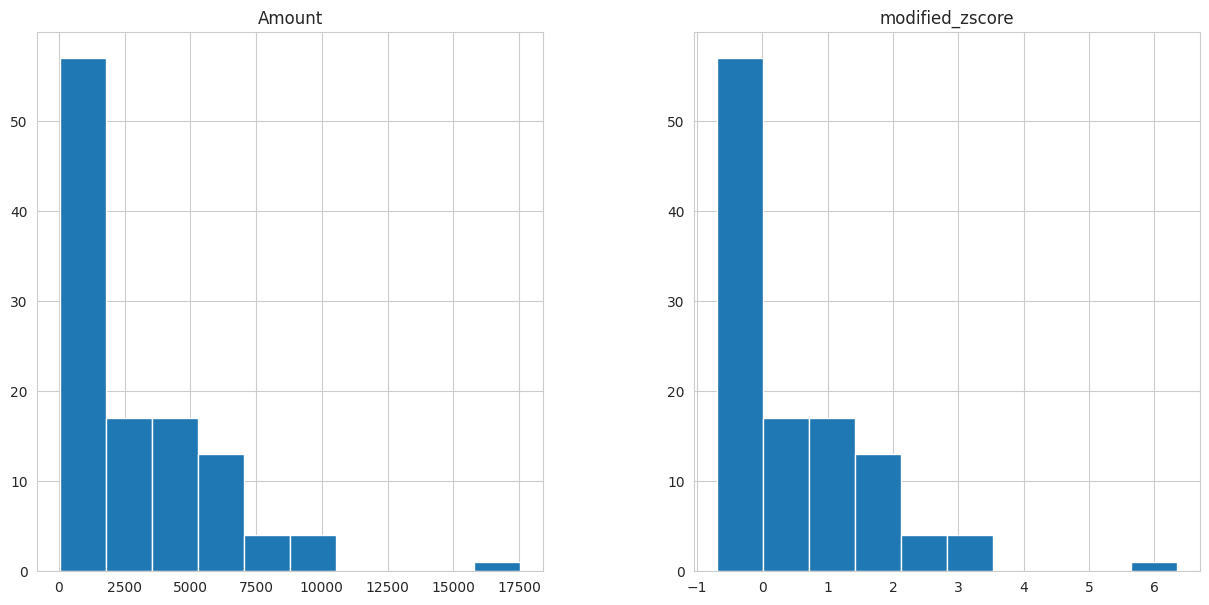

In [28]:
threshold = 3
outliers, transformed_data = modified_z_score(transaction_df, threshold)

transformed_data.hist()

In [29]:
outliers

Transaction_Date
2022-04-27    10022.400000
2023-01-25    17522.400000
2024-12-18     9375.458621
Name: Amount, dtype: float64

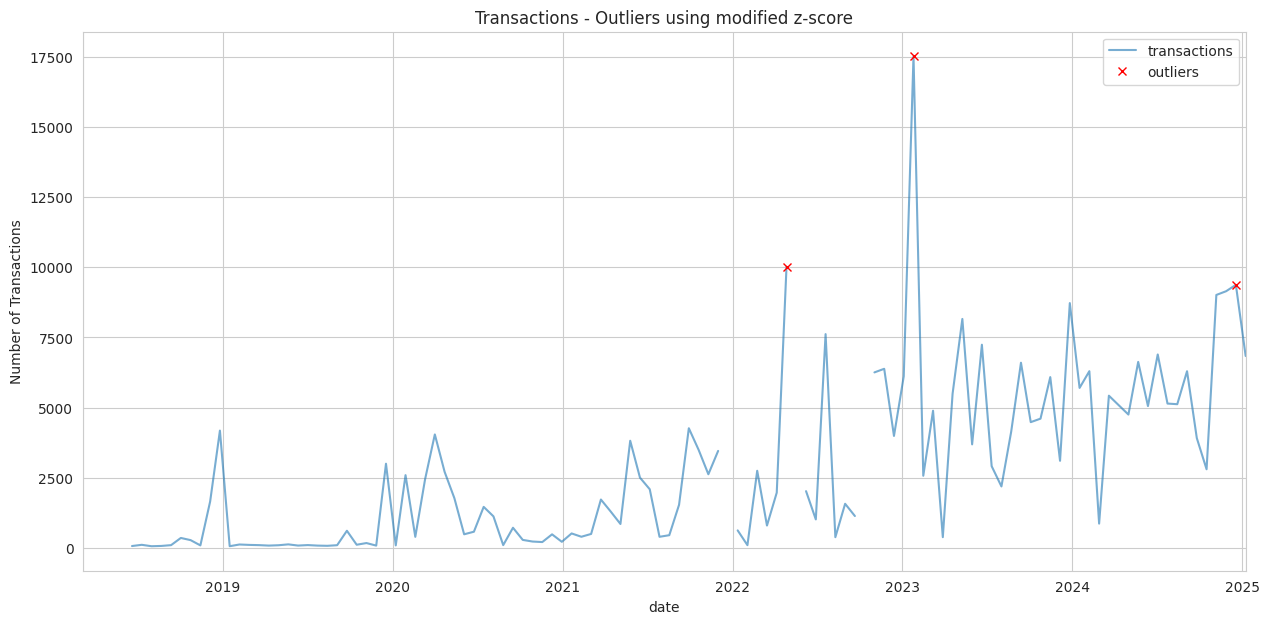

In [30]:
plot_outliers(outliers, transaction_df, "Outliers using modified z-score")

In [31]:
def plot_modified_zscore(df, degree=3):
    n = len(df)

    plt.figure(figsize=(8,8))
    plt.plot(df, 'k^')
    plt.plot([0,n],[degree,degree],'r--')
    plt.plot([0,n],[-degree,-degree],'r--')
    plt.show()

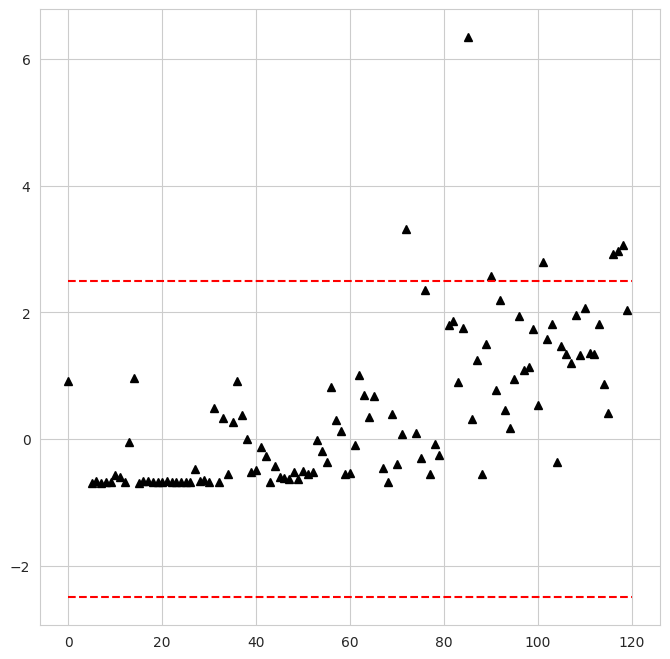

In [32]:
data = transformed_data['modified_zscore'].values
plot_modified_zscore(data, degree=2.5)

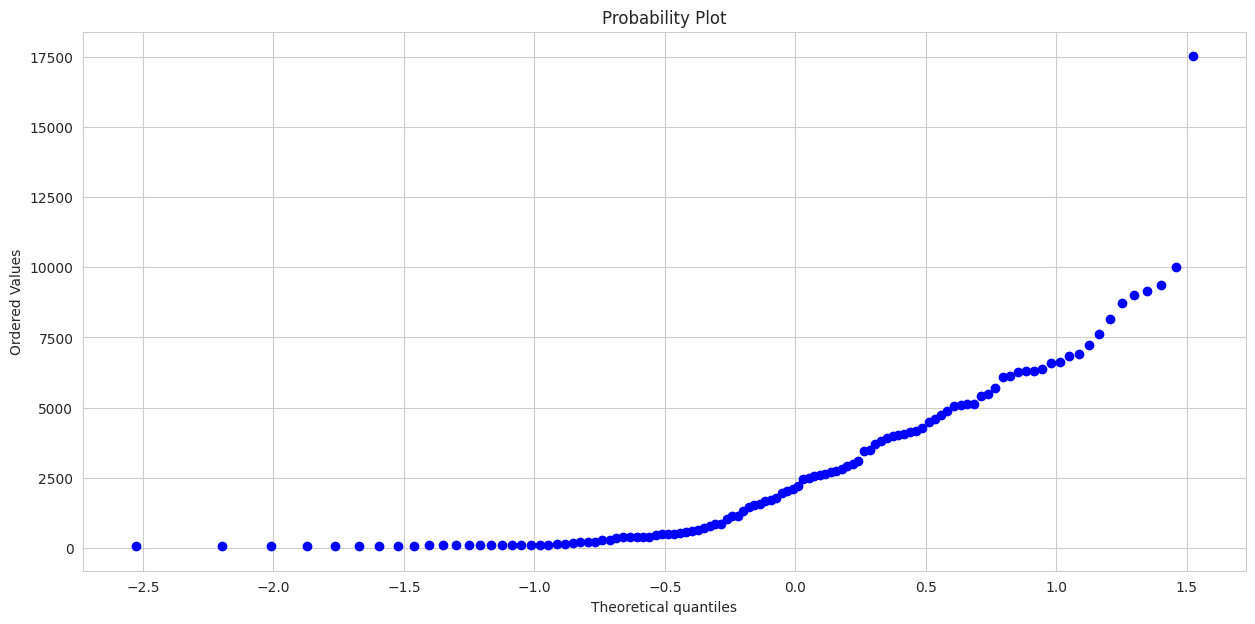

In [33]:
res = scipy.stats.probplot(transaction_df.values.reshape(-1), plot=plt)

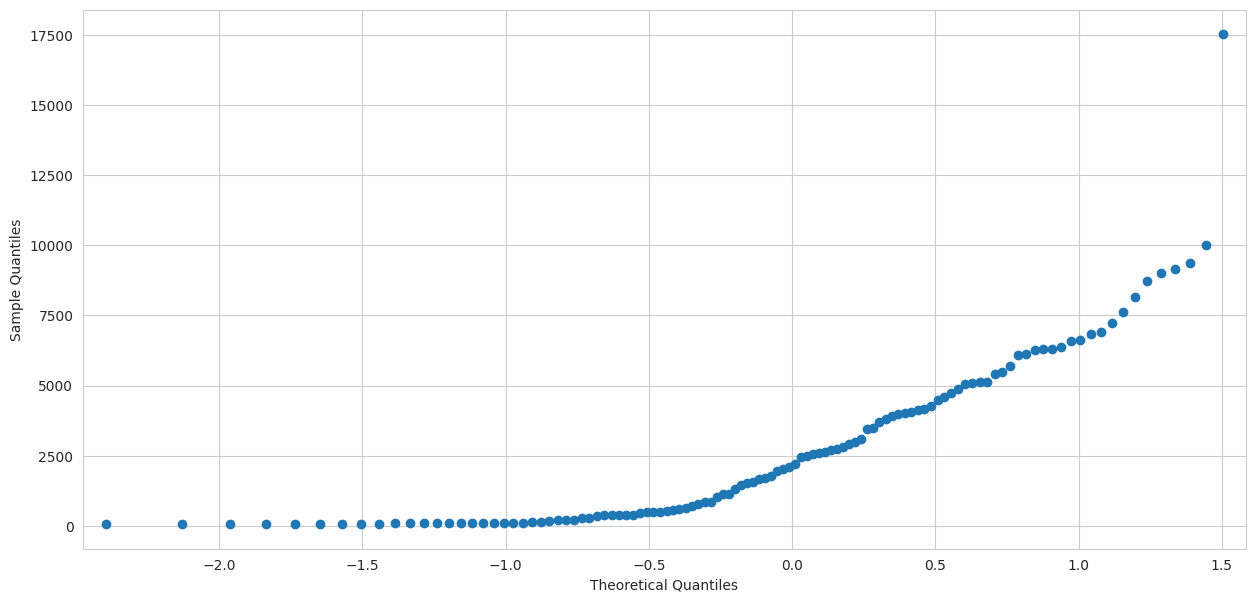

In [34]:
qqplot(transaction_df.values.reshape(-1), line='s')
plt.show()

### Outlier detection using unsupervised ml

In [47]:
knn = KNN(contamination=0.03, method='mean', n_neighbors=10)
transaction_df = transaction_df.ffill()
knn.fit(transaction_df)

KNN(algorithm='auto', contamination=0.03, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=10, p=2,
  radius=1.0)

In [49]:
predicted = pd.Series(knn.predict(transaction_df), index=transaction_df.index)
print('Total number of outliers = ', predicted.sum())

Total number of outliers =  3


In [50]:
predicted

Transaction_Date
2018-03-07    0
2018-03-28    0
2018-04-18    0
2018-05-09    0
2018-05-30    0
             ..
2024-10-16    0
2024-11-06    0
2024-11-27    0
2024-12-18    0
2025-01-08    0
Freq: 21D, Length: 120, dtype: int64

In [52]:
outliers = predicted[predicted == 1]
outliers = transaction_df.loc[outliers.index]
outliers

,Amount
Transaction_Date,
2022-04-27,10022.4
2022-05-18,10022.4
2023-01-25,17522.4


We still have got 3 outliers by using k nearest neighbors.

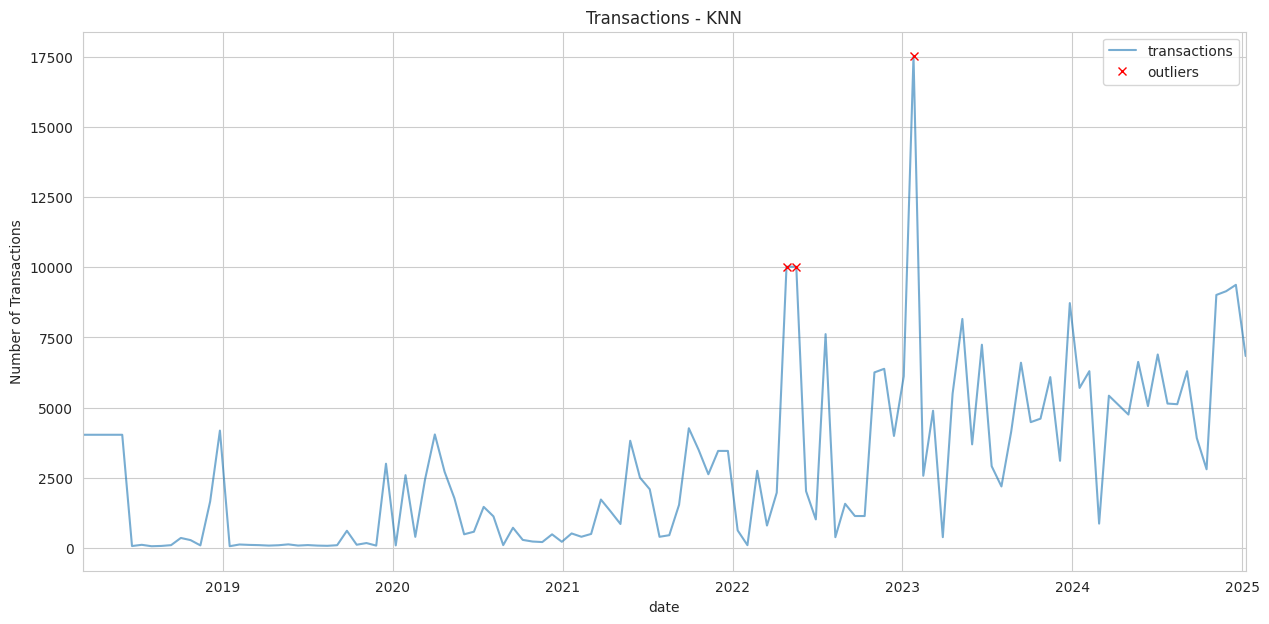

In [53]:
plot_outliers(outliers, transaction_df, 'KNN')

In [65]:
class DifferentOutlierDetectors:
    def __init__(self, df):
        self.df = df
        self.models = {}
        self.fitted_models = {}

    def instantiate_model(self, model_name, **kwargs):
        """
        Dynamically instantiate an outlier detection model.
        
        Args:
            model_name (str): Name of the model to instantiate (e.g., 'KNN', 'LOF', etc.).
            kwargs: Additional parameters to pass to the model constructor.
        
        Raises:
            ValueError: If the model name is not recognized.
        """
        model_mapping = {
            'KNN': KNN,
            'LOF': LOF,
            'CBLOF': CBLOF,
            'IForest': IForest,
            'COPOD': COPOD,
            'MAD': MAD,  # Placeholder for a custom implementation
            'OCSVM': OCSVM,
        }

        if model_name not in model_mapping:
            raise ValueError(f"Model '{model_name}' is not recognized. Available models: {list(model_mapping.keys())}")
        
        model_class = model_mapping[model_name]
        if model_class is None:
            raise NotImplementedError(f"The model '{model_name}' is not yet implemented.")
        
        # Instantiate the model with provided parameters
        model = model_class(**kwargs)
        self.models[model_name] = model
        return model
    
    def fit(self, model_name, X):
        """
        Fit the specified model to the data.
        
        Args:
            model_name (str): Name of the model to fit.
            X (array-like): Input features for fitting the model.
        """
        if model_name not in self.models:
            raise ValueError(f"Model '{model_name}' has not been instantiated. Call 'instantiate_model' first.")
        
        model = self.models[model_name]
        model.fit(X)
        self.fitted_models[model_name] = model

    def predict(self, model_name, X):
        """
        Predict outliers using the specified model.
        
        Args:
            model_name (str): Name of the model to use for predictions.
            X (array-like): Input features for prediction.
        
        Returns:
            np.ndarray: Binary labels for outliers (1 for outlier, 0 for inlier).
        """
        if model_name not in self.fitted_models:
            raise ValueError(f"Model '{model_name}' has not been fitted. Call 'fit' first.")
        
        model = self.fitted_models[model_name]
        predicted = model.predict(X)
        return predicted
    
    def plot_outliers(self, outliers, df, model_name='KNN', halignment='right', valignment='bottom', labels=False):
        """
        Plots outliers on a time-series-like plot.
        
        Parameters:
        outliers: DataFrame containing known outliers.
        df: DataFrame to check and plot the outliers.
        method: String, the name of the method used for detection.
        halignment: Horizontal alignment for labels.
        valignment: Vertical alignment for labels.
        labels: Boolean, whether to display labels for outliers.
        """
        ax = df.plot(alpha=0.6)

        if labels:
            for i in outliers['value'].items():
                plt.plot(i[0], i[1], 'rx', markersize=8, markerfacecolor='none', markeredgecolor='k')
                plt.text(i[0], i[1], f'{i[0].date()}', horizontalalignment=halignment, verticalalignment=valignment)
        else:
            df.loc[outliers.index].plot(ax=ax, style='rx')

        plt.title(f'Transactions - {model_name}')
        plt.xlabel('Date')
        plt.ylabel('Number of Transactions')
        plt.legend(['Transactions', 'Outliers'])
        plt.show()


In [66]:
outlier_detector = DifferentOutlierDetectors(transaction_df)

outlier_detector.instantiate_model('LOF', contamination=0.09, n_neighbors=10)
outlier_detector.fit('LOF', transaction_df.values)

predicted = outlier_detector.predict('LOF', transaction_df.values)

outliers = transaction_df[predicted == 1]
# outliers = transaction_df.loc[outliers.index]
outliers


,Amount
Transaction_Date,
2019-05-22,126.176471
2019-11-06,172.915254
2020-10-28,227.082192
2020-11-18,208.338308
2020-12-30,217.490190
2022-04-27,10022.400000
2022-05-18,10022.400000
2023-01-25,17522.400000


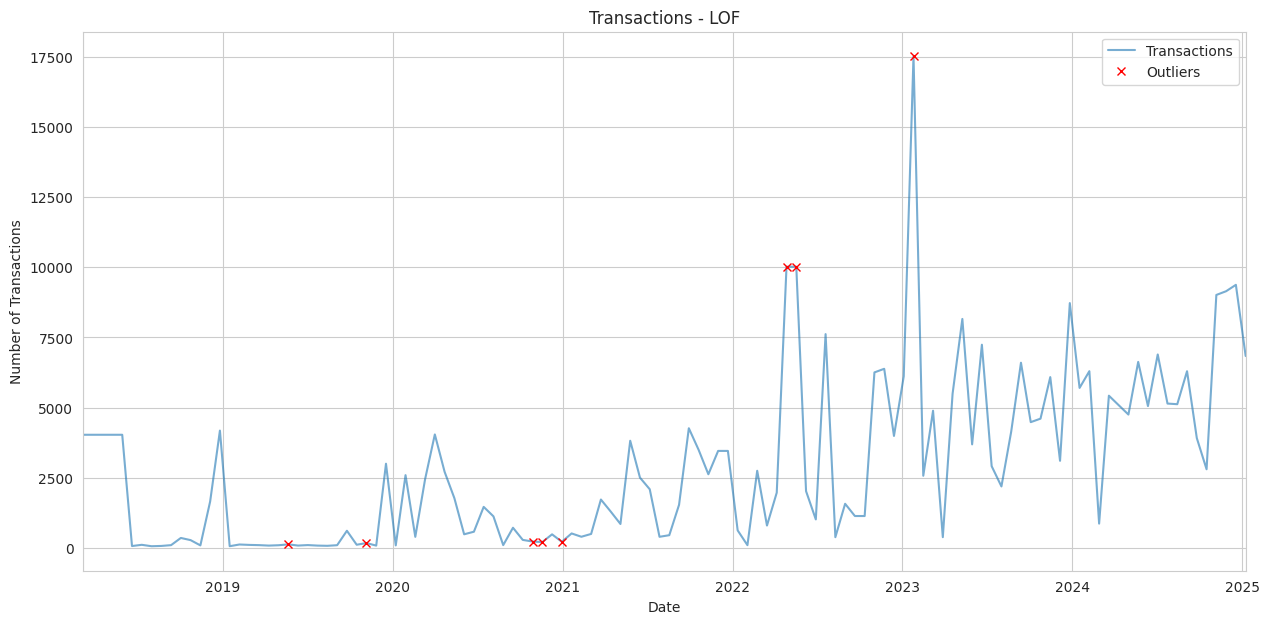

In [69]:
outlier_detector.plot_outliers(outliers, transaction_df, 'LOF')